In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [ ]:
np.random.seed(42)

produtos = {
    "Dom Casmurro":       ("Literatura", 35.90),
    "O Pequeno Príncipe": ("Infantil",   29.90),
    "Sapiens":             ("Ciências",   54.90),
    "Python para Dados":  ("Tecnologia", 89.90),
    "Clean Code":         ("Tecnologia", 95.00),
    "Harry Potter Vol.1": ("Fantasia",   49.90),
    "Atomic Habits":      ("Autoajuda",  44.90),
    "A Arte da Guerra":   ("Filosofia",  32.00),
    "Cosmos":             ("Ciências",   62.50),
    "Cem Anos de Solidão":("Literatura", 39.90),
}

vendedores = ["Ana Lima", "Carlos Mendes", "Bruno Costa", "Fernanda Rocha"]
regioes    = ["Sudeste", "Sul", "Nordeste", "Norte", "Centro-Oeste"]
datas      = pd.date_range("2024-01-01", "2024-06-30", periods=50)

nomes_prod = np.random.choice(list(produtos.keys()), 50)

dados = {
    "id_venda":   range(1, 51),
    "data":       datas.strftime("%Y-%m-%d"),
    "produto":    nomes_prod,
    "categoria":  [produtos[p][0] for p in nomes_prod],
    "quantidade": np.random.randint(1, 6, 50),
    "preco_unit": [produtos[p][1] for p in nomes_prod],
    "vendedor":   np.random.choice(vendedores, 50),
    "regiao":     np.random.choice(regioes, 50),
}

df = pd.DataFrame(dados)
df["total_venda"] = df["quantidade"] * df["preco_unit"]

# Salva como CSV
df.to_csv("vendas_livraria.csv", index=False)

print(f"Dataset criado! Shape: {df.shape}")
print(f"Colunas: {list(df.columns)}")
df.head()

Dataset criado! Shape: (50, 9)
Colunas: ['id_venda', 'data', 'produto', 'categoria', 'quantidade', 'preco_unit', 'vendedor', 'regiao', 'total_venda']


,id_venda,data,produto,categoria,quantidade,preco_unit,vendedor,regiao,total_venda
0,1,2024-01-01,Atomic Habits,Autoajuda,3,44.9,Ana Lima,Centro-Oeste,134.7
1,2,2024-01-04,Python para Dados,Tecnologia,1,89.9,Fernanda Rocha,Norte,89.9
2,3,2024-01-08,A Arte da Guerra,Filosofia,4,32.0,Bruno Costa,Centro-Oeste,128.0
3,4,2024-01-12,Clean Code,Tecnologia,2,95.0,Bruno Costa,Nordeste,190.0
4,5,2024-01-15,Atomic Habits,Autoajuda,4,44.9,Carlos Mendes,Nordeste,179.6


In [ ]:
df = pd.read_csv("vendas_livraria.csv")

print("═" * 45)
print("INFORMAÇÕES DO DATASET")
print("═" * 45)
print(f"Linhas:   {df.shape[0]}")
print(f"Colunas:  {df.shape[1]}")

print("\n TIPOS DE DADOS:")
print(df.dtypes)

print("\n VALORES NULOS:")
print(df.isnull().sum())

print("\n ESTATÍSTICAS DESCRITIVAS:")
df[["quantidade", "preco_unit", "total_venda"]].describe().round(2)

═════════════════════════════════════════════
INFORMAÇÕES DO DATASET
═════════════════════════════════════════════
Linhas:   50
Colunas:  9

 TIPOS DE DADOS:
id_venda         int64
data            object
produto         object
categoria       object
quantidade       int64
preco_unit     float64
vendedor        object
regiao          object
total_venda    float64
dtype: object

 VALORES NULOS:
id_venda       0
data           0
produto        0
categoria      0
quantidade     0
preco_unit     0
vendedor       0
regiao         0
total_venda    0
dtype: int64

 ESTATÍSTICAS DESCRITIVAS:


,quantidade,preco_unit,total_venda
count,50.00,50.00,50.00
mean,2.84,55.57,150.77
std,1.45,23.27,98.01
min,1.00,29.90,29.90
25%,2.00,36.90,79.80
50%,3.00,47.40,128.00
75%,4.00,62.50,190.00
max,5.00,95.00,475.00


In [ ]:
total = df["total_venda"].sum()
print(f"Faturamento Total: R$ {total:,.2f}")

print("\nFaturamento por Categoria:")
cat_fat = (df.groupby("categoria")["total_venda"]
             .sum()
             .sort_values(ascending=False))
print(cat_fat.apply(lambda x: f"R$ {x:,.2f}"))

print("\nRanking de Vendedores:")
vend_rank = (df.groupby("vendedor")["total_venda"]
               .sum()
               .sort_values(ascending=False))
print(vend_rank.apply(lambda x: f"R$ {x:,.2f}"))

print("\nTop 3 Produtos (qtd vendida):")
top_prod = (df.groupby("produto")["quantidade"]
              .sum()
              .sort_values(ascending=False)
              .head(3))
print(top_prod)

print("\nTicket Médio por Região:")
reg_media = (df.groupby("regiao")["total_venda"]
               .mean()
               .sort_values(ascending=False)
               .round(2))
print(reg_media.apply(lambda x: f"R$ {x:,.2f}"))

Faturamento Total: R$ 7,538.40

Faturamento por Categoria:
categoria
Tecnologia    R$ 2,788.80
Autoajuda     R$ 1,122.50
Ciências      R$ 1,071.80
Literatura      R$ 813.90
Filosofia       R$ 704.00
Fantasia        R$ 648.70
Infantil        R$ 388.70
Name: total_venda, dtype: object

Ranking de Vendedores:
vendedor
Bruno Costa       R$ 3,392.90
Ana Lima          R$ 1,700.80
Fernanda Rocha    R$ 1,361.10
Carlos Mendes     R$ 1,083.60
Name: total_venda, dtype: object

Top 3 Produtos (qtd vendida):
produto
Atomic Habits       25
A Arte da Guerra    22
Clean Code          18
Name: quantidade, dtype: int64

Ticket Médio por Região:
regiao
Nordeste        R$ 178.94
Norte           R$ 164.88
Sudeste         R$ 135.95
Centro-Oeste    R$ 135.26
Sul             R$ 133.08
Name: total_venda, dtype: object


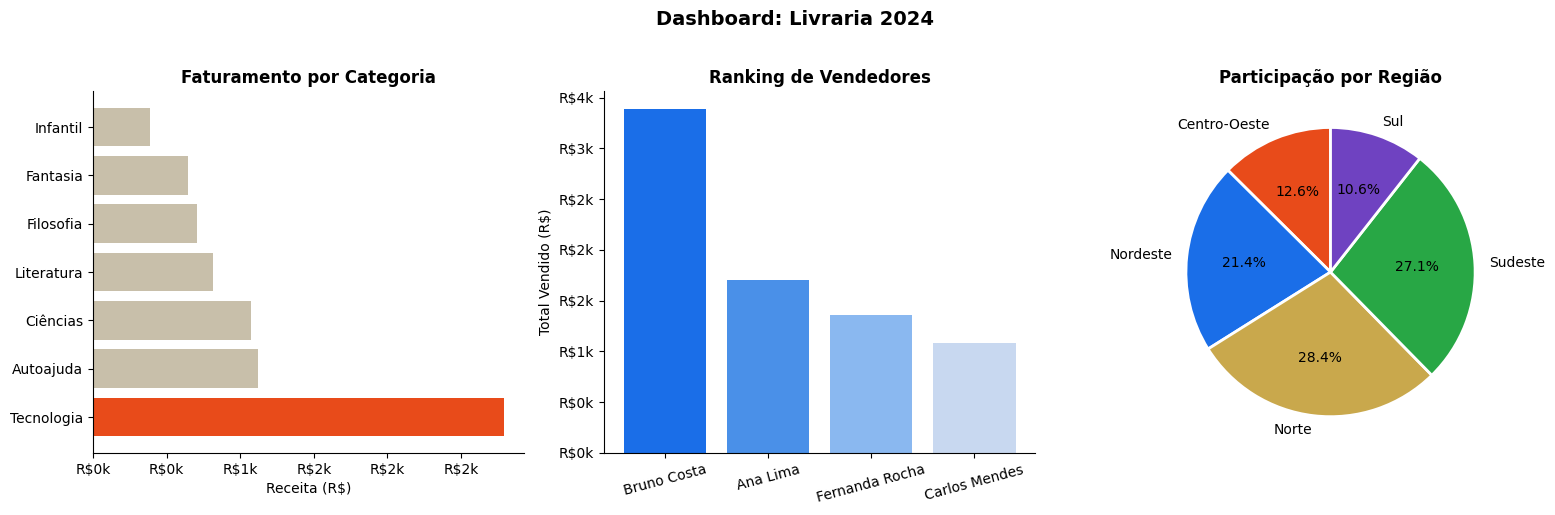

Gráficos salvos em dashboard_livraria.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Dashboard: Livraria 2024",
             fontsize=14, fontweight="bold", y=1.02)

ax1 = axes[0]
cores = ["#e84b1a" if i==0 else "#c8bfaa" for i in range(len(cat_fat))]
ax1.barh(cat_fat.index, cat_fat.values, color=cores)
ax1.set_title("Faturamento por Categoria", fontweight="bold")
ax1.set_xlabel("Receita (R$)")
ax1.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x/1000:.0f}k"))

ax2 = axes[1]
ax2.bar(vend_rank.index, vend_rank.values,
        color=["#1a6ee8","#4a90e8","#8ab8f0","#c8d8f0"])
ax2.set_title("Ranking de Vendedores", fontweight="bold")
ax2.set_ylabel("Total Vendido (R$)")
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f"R${y/1000:.0f}k"))
ax2.tick_params(axis="x", rotation=15)

ax3 = axes[2]
reg_total = df.groupby("regiao")["total_venda"].sum()
ax3.pie(reg_total, labels=reg_total.index,
        autopct="%1.1f%%",
        colors=["#e84b1a","#1a6ee8","#c9a84c","#28a745","#6f42c1"],
        startangle=90,
        wedgeprops={"edgecolor":"white", "linewidth":2})
ax3.set_title("Participação por Região", fontweight="bold")

plt.tight_layout()
plt.savefig("dashboard_livraria.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráficos salvos em dashboard_livraria.png")

In [ ]:
df["data"] = pd.to_datetime(df["data"])

df["mes"] = df["data"].dt.to_period("M")

fat_mensal = df.groupby("mes")["total_venda"].sum().sort_index()

print("\nFaturamento mês a mês:")
print(fat_mensal.apply(lambda x: f"R$ {x:,.2f}"))


Faturamento mês a mês:
mes
2024-01    R$ 1,251.40
2024-02    R$ 1,281.10
2024-03    R$ 1,505.60
2024-04    R$ 1,284.40
2024-05    R$ 1,263.50
2024-06      R$ 952.40
Freq: M, Name: total_venda, dtype: object


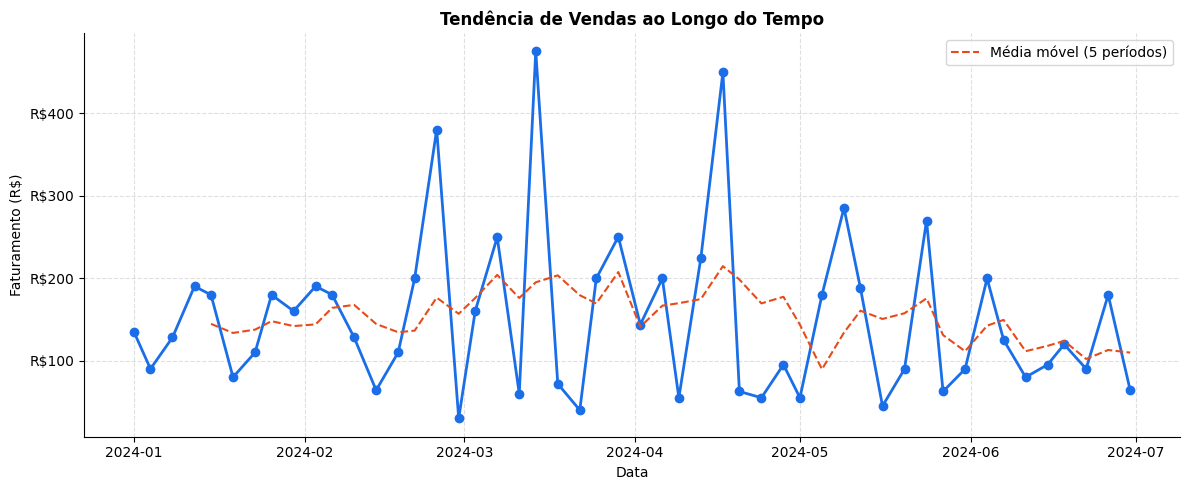

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

df["data"] = pd.to_datetime(df["data"])

vendas_tempo = (df.groupby("data")["total_venda"]
                  .sum()
                  .sort_index())

plt.figure(figsize=(12, 5))

plt.plot(vendas_tempo.index,
         vendas_tempo.values,
         marker="o",
         linestyle="-",
         color="#1a6ee8",
         linewidth=2)

media_movel = vendas_tempo.rolling(window=5).mean()
plt.plot(vendas_tempo.index,
         media_movel,
         linestyle="--",
         color="#e84b1a",
         label="Média móvel (5 períodos)")

plt.title("Tendência de Vendas ao Longo do Tempo", fontweight="bold")
plt.xlabel("Data")
plt.ylabel("Faturamento (R$)")

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}")
)

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
df["data"] = pd.to_datetime(df["data"])

ticket_medio = (df.groupby("vendedor")["total_venda"]
                  .mean()
                  .sort_values(ascending=False))

print("\nTicket médio por vendedor:")
print(ticket_medio.apply(lambda x: f"R$ {x:,.2f}"))

top_vendedor = ticket_medio.idxmax()
valor_top = ticket_medio.max()

print(f"\n🏆 Vendedor com maior ticket médio: {top_vendedor}")
print(f"💰 Ticket médio: R$ {valor_top:,.2f}")


Ticket médio por vendedor:
vendedor
Bruno Costa       R$ 161.57
Fernanda Rocha    R$ 151.23
Ana Lima          R$ 141.73
Carlos Mendes     R$ 135.45
Name: total_venda, dtype: object

🏆 Vendedor com maior ticket médio: Bruno Costa
💰 Ticket médio: R$ 161.57


In [ ]:
df["data"] = pd.to_datetime(df["data"])

df_alto_valor = df[df["total_venda"] > 200]

print(f"Quantidade de vendas > R$200: {len(df_alto_valor)}")

cat_alto = (df_alto_valor.groupby("categoria")["total_venda"]
              .sum()
              .sort_values(ascending=False))

print("\nFaturamento por categoria (vendas > R$200):")
print(cat_alto.apply(lambda x: f"R$ {x:,.2f}"))

cat_qtd = (df_alto_valor["categoria"]
             .value_counts())

print("\nQuantidade de vendas por categoria:")
print(cat_qtd)

top_categoria = cat_alto.idxmax()
valor_top = cat_alto.max()

print(f"\n🏆 Categoria dominante em vendas de alto valor: {top_categoria}")
print(f"💰 Faturamento: R$ {valor_top:,.2f}")

Quantidade de vendas > R$200: 8

Faturamento por categoria (vendas > R$200):
categoria
Tecnologia    R$ 1,859.20
Ciências        R$ 250.00
Fantasia        R$ 249.50
Autoajuda       R$ 224.50
Name: total_venda, dtype: object

Quantidade de vendas por categoria:
categoria
Tecnologia    5
Fantasia      1
Ciências      1
Autoajuda     1
Name: count, dtype: int64

🏆 Categoria dominante em vendas de alto valor: Tecnologia
💰 Faturamento: R$ 1,859.20


In [ ]:
import numpy as np

linhas_nulas = pd.DataFrame(np.nan, index=range(5), columns=df.columns)

df = pd.concat([df, linhas_nulas], ignore_index=True)

print("Novas dimensões do dataset:", df.shape)

print("\nValores nulos por coluna:")
print(df.isnull().sum())

print("\nLinhas com valores nulos:")
print(df[df.isnull().any(axis=1)])

Novas dimensões do dataset: (65, 10)

Valores nulos por coluna:
id_venda       15
data           15
produto        15
categoria      15
quantidade     15
preco_unit     15
vendedor       15
regiao         15
total_venda    15
mes            15
dtype: int64

Linhas com valores nulos:
    id_venda data produto categoria  quantidade  preco_unit vendedor regiao  \
50       NaN  NaT     NaN       NaN         NaN         NaN      NaN    NaN   
51       NaN  NaT     NaN       NaN         NaN         NaN      NaN    NaN   
52       NaN  NaT     NaN       NaN         NaN         NaN      NaN    NaN   
53       NaN  NaT     NaN       NaN         NaN         NaN      NaN    NaN   
54       NaN  NaT     NaN       NaN         NaN         NaN      NaN    NaN   
55       NaN  NaT     NaN       NaN         NaN         NaN      NaN    NaN   
56       NaN  NaT     NaN       NaN         NaN         NaN      NaN    NaN   
57       NaN  NaT     NaN       NaN         NaN         NaN      NaN    NaN   
58   

/tmp/ipykernel_48211/3664311320.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, linhas_nulas], ignore_index=True)


In [ ]:
df_drop = df.dropna()

print("\nDataset após remover nulos:")
print(df_drop.shape)


Dataset após remover nulos:
(50, 10)
